[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter0_lecture_notebook.ipynb)

# Chapter 0: Financial Markets in 2026 — Lecture Notebook

**Modelling Financial Markets (MFM)**, Master's programme *Applied Statistics and Data Science*, Bucharest University of Economic Studies

*Daniel Traian Pele*

This notebook reproduces every chart of the Chapter 0 lecture on real data (2000–2026).

- Daily market data are read from `data/market` (local copy of the repository, or GitHub).
- Public sources: FRED, BNR, DefiLlama.
- Run all cells from top to bottom; it takes well under a minute.

## 0. Setup

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_0'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/2026 MFM/MFM/notebooks/EN


In [2]:
import os
import io
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

In [3]:
# MFM chart style: transparent background, English labels, legend below
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Brand colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
Teal     = '#17A2B8'


def save_fig(name):
    """Show the chart inline"""
    plt.show()
    plt.close()


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def log_axis(ax, ticks):
    """Axa logaritmica cu etichete lizibile (fara notatie stiintifica)."""
    ax.set_yscale('log')
    ax.set_yticks(ticks)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.yaxis.set_minor_formatter(plt.NullFormatter())

### Data loader

Every series goes through one function, `fetch_daily(symbol, source, field)`. Stocks and ETFs use `adjusted_close` (dividends and splits); indices, FX, crypto and yields use `close`.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
LOCAL_DIRS = ['../../data/market', '../data/market', 'data/market']   # cloned repository
START, END = '2000-01-01', '2026-09-18'

# name -> (source, symbol, field)
SERIES = {
    'S&P 500': ('market', 'GSPC.INDX', 'close'),
    'Euro Stoxx 50': ('market', 'STOXX50E.INDX', 'close'),
    'Nikkei 225': ('market', 'N225.INDX', 'close'),
    'VIX': ('market', 'VIX.INDX', 'close'),
    'BET-TR': ('market', 'BETTR.INDX', 'close'),
    'BET': ('market', 'BET', 'close'),
    'BET-XT': ('market', 'BETXT.INDX', 'close'),
    'US Treasuries 20y+ (TLT)': ('market', 'TLT.US', 'adjusted_close'),
    'SPY': ('market', 'SPY.US', 'adjusted_close'),
    'RSP': ('market', 'RSP.US', 'adjusted_close'),
    'IBIT': ('market', 'IBIT.US', 'close'),
    'IBIT volume': ('market', 'IBIT.US', 'volume'),
    'Gold': ('market', 'XAUUSD.FOREX', 'close'),
    'EUR/USD': ('market', 'EURUSD.FOREX', 'close'),
    'EUR/RON (market file)': ('market', 'EURRON.FOREX', 'close'),
    'Bitcoin': ('market', 'BTC-USD.CC', 'close'),
    'Ethereum': ('market', 'ETH-USD.CC', 'close'),
    'Romania 10y': ('market', 'RO10Y.GBOND', 'close'),
    'Germany 10y': ('market', 'DE10Y.GBOND', 'close'),
    'Banca Transilvania': ('market', 'TLV.RO', 'adjusted_close'),
    'OMV Petrom': ('market', 'SNP.RO', 'adjusted_close'),
    'BRD': ('market', 'BRD.RO', 'adjusted_close'),
    'Transgaz': ('market', 'TGN.RO', 'adjusted_close'),
    'Romgaz': ('market', 'SNG.RO', 'adjusted_close'),
    'Hidroelectrica': ('market', 'H2O.RO', 'adjusted_close'),
    'EUR/RON': ('bnr', 'EUR', None),
    'DGS10': ('fred', 'DGS10', None),
    'DGS2': ('fred', 'DGS2', None),
    'FEDFUNDS': ('fred', 'FEDFUNDS', None),
    'USD per EUR': ('fred', 'DEXUSEU', None),
    'JPY per USD': ('fred', 'DEXJPUS', None),
    'T10Y2Y': ('fred', 'T10Y2Y', None),
    'ETF equities': ('fred', 'BOGZ1LM563064100Q', None),
    'All equities': ('fred', 'BOGZ1LM893064105Q', None),
    'Stablecoins': ('defillama', 'stablecoincharts/all', None),
}


def read_market(symbol):
    """Daily market file: local copy if the repository is cloned, otherwise GitHub"""
    for d in LOCAL_DIRS:
        path = os.path.join(d, f'{symbol}.csv')
        if os.path.exists(path):
            return pd.read_csv(path, index_col='date', parse_dates=True)
    return pd.read_csv(REPO_RAW + f'{symbol}.csv', index_col='date', parse_dates=True)


def fetch_daily(symbol, source='market', field='close', start=START, end=END):
    """Punctul unic de acces la date: intoarce o pd.Series zilnica (fara NaN)."""
    if source == 'market':
        s = read_market(symbol)[field]
    elif source == 'fred':
        raw = urllib.request.urlopen(
            f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={symbol}', timeout=90).read().decode()
        s = pd.read_csv(io.StringIO(raw), index_col=0, parse_dates=True, na_values='.').iloc[:, 0]
    elif source == 'defillama':
        req = urllib.request.Request(f'https://stablecoins.llama.fi/{symbol}',
                                     headers={'User-Agent': 'Mozilla/5.0'})
        d = json.load(urllib.request.urlopen(req, timeout=90))
        s = pd.Series({pd.to_datetime(int(x['date']), unit='s'): x['totalCirculatingUSD'].get('peggedUSD', 0)
                       for x in d}) / 1e9                                   # miliarde USD
    elif source == 'bnr':
        # cursul oficial BNR (RON pentru o unitate de valuta), arhive XML anuale
        import re
        rows = []
        for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
            url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
            xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                         timeout=90).read().decode()
            for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
                m = re.search(rf'<Rate currency="{symbol}">([\d.]+)</Rate>', body)
                if m:
                    rows.append((d, float(m.group(1))))
        s = pd.Series(dict(rows))
    else:
        raise ValueError(f'unknown source: {source}')
    s = pd.to_numeric(s, errors='coerce')
    s.index = pd.to_datetime(s.index)
    s.index.name = 'Date'
    return s.sort_index().loc[start:end].dropna()


WEEKDAYS_ONLY = {'EUR/USD', 'Gold'}   # FX/OTC quotes: weekend prints break the Friday-Monday return


def load(name, start=START, end=END):
    """Seria cu numele din SERIES (pentru aur si EUR/USD: doar zilele lucratoare)."""
    source, symbol, field = SERIES[name]
    s = fetch_daily(symbol, source, field, start, end).rename(name)
    if name in WEEKDAYS_ONLY:
        s = s[s.index.dayofweek < 5]
    return s


def load_panel(names, start=START, end=END):
    """Mai multe serii aliniate pe data (NaN acolo unde o piata nu tranzactioneaza)."""
    return pd.concat([load(n, start, end) for n in names], axis=1)

In [5]:
ASSET_NAMES = ['S&P 500', 'Euro Stoxx 50', 'Nikkei 225', 'Gold', 'US Treasuries 20y+ (TLT)', 'Bitcoin',
               'Ethereum', 'VIX', 'SPY', 'RSP', 'IBIT', 'EUR/USD', 'BET-TR']
BVB_NAMES = ['Banca Transilvania', 'OMV Petrom', 'BRD', 'Transgaz', 'Romgaz', 'Hidroelectrica']

px = load_panel(ASSET_NAMES)                        # daily market data
bvb = load_panel(BVB_NAMES)                         # adjusted_close
ibit_volume = load('IBIT volume')
fred = load_panel(['DGS10', 'DGS2', 'FEDFUNDS'])    # FRED
fx_usd = load_panel(['USD per EUR', 'JPY per USD'])  # FRED exchange rates
stable = load('Stablecoins')                        # DefiLlama (bn USD)
eurron = load('EUR/RON')                            # BNR official reference rate
eurron_mkt = load('EUR/RON (market file)')          # market file, contains bad ticks
bonds = load_panel(['Romania 10y', 'Germany 10y'])
print(px.shape, bvb.shape, fred.shape, len(stable), len(eurron))

(8656, 13) (6900, 6) (6798, 3) 3216 5480


In [6]:
CROSS = ['S&P 500 TR (SPY)', 'Euro Stoxx 50 (USD)', 'Nikkei 225 (USD)', 'Gold', 'US Treasuries 20y+ (TLT)', 'Bitcoin']
CROSS_COL = [MainBlue, Forest, Purple, Amber, '#17A2B8', Orange]
OFFSETS = {'Gold': (-7, 2, 'right'), 'S&P 500 TR (SPY)': (0, 8, 'center'), 'Nikkei 225 (USD)': (7, 2, 'left'), 'Euro Stoxx 50 (USD)': (7, -7, 'left'), 'US Treasuries 20y+ (TLT)': (-7, -9, 'right'), 'EUR/USD': (0, 7, 'center'), 'EUR/RON': (6, 3, 'left'), 'Bitcoin': (-6, 3, 'right'), 'Ethereum': (-6, 3, 'right')}
EPISODES = [('Dot-com', '2000-01-01', '2003-12-31'), ('Global Financial Crisis', '2007-06-01', '2010-12-31'), ('COVID-19', '2020-01-01', '2020-12-31'), ('2022 inflation shock', '2022-01-01', '2023-12-31')]


def clean_series(y, max_dev=1.0, window=11):
    """Elimina weekend-urile si punctele aflate la peste max_dev de mediana mobila centrata."""
    y = y[y.index.dayofweek < 5]
    med = y.rolling(window, center=True, min_periods=3).median()
    return y[(y - med).abs() <= max_dev]


def drawdown(p):
    """Drawdown fata de maximul anterior: P_t / max_{s<=t} P_s - 1."""
    return p / p.cummax() - 1


def ann_stats(p, periods=252):
    """Randament anualizat (CAGR) si volatilitate anualizata din preturi zilnice.

    periods='obs' foloseste numarul efectiv de observatii pe an al seriei.
    """
    p = p.dropna()
    years = (p.index[-1] - p.index[0]).days / 365.25
    cagr = (p.iloc[-1] / p.iloc[0]) ** (1 / years) - 1
    r = np.log(p).diff().dropna()
    if periods == 'obs':
        periods = len(r) / years
    return cagr, r.std() * np.sqrt(periods)


def to_usd(local, fx, invert=False):
    """Converteste un indice in moneda locala in USD cu cursul FRED din aceeasi zi
    (ultimul curs disponibil, cel mult 5 zile in urma, daca ziua lipseste)."""
    f = fx.dropna().reindex(local.index, method='ffill', tolerance=pd.Timedelta(days=5))
    return (local / f if invert else local * f).dropna()


def cross_panel():
    """Seriile comparate pe clase de active, toate in USD:
    S&P 500 = SPY ajustat (randament total); Euro Stoxx 50 si Nikkei 225 = indici de pret convertiti in USD;
    TLT = randament total; aur = spot; Bitcoin = pret."""
    return {
        'S&P 500 TR (SPY)': px['SPY'].dropna(),
        'Euro Stoxx 50 (USD)': to_usd(px['Euro Stoxx 50'].dropna(), fx_usd['USD per EUR']),
        'Nikkei 225 (USD)': to_usd(px['Nikkei 225'].dropna(), fx_usd['JPY per USD'], invert=True),
        'Gold': px['Gold'].dropna(),
        'US Treasuries 20y+ (TLT)': px['US Treasuries 20y+ (TLT)'].dropna(),
        'Bitcoin': px['Bitcoin'].dropna(),
        'Ethereum': px['Ethereum'].dropna(),
        'EUR/USD': px['EUR/USD'].dropna(),
    }


def dividend_gap(start='2015-01-02'):
    """Diferenta de CAGR dintre S&P 500 cu dividende reinvestite (SPY ajustat) si indicele de pret."""
    c_tr, _ = ann_stats(px['SPY'].loc[start:])
    c_px, _ = ann_stats(px['S&P 500'].loc[start:])
    return c_tr, c_px, c_tr - c_px

## 1. Asset classes since 2015

Growth of 1 USD invested on 2 January 2015 (log scale), every series in USD. S&P 500 = SPY with dividends reinvested (total return); Euro Stoxx 50 and Nikkei 225 = price indices (no dividends) converted to USD with FRED exchange rates; TLT = total return; gold = spot.

In [7]:
def fig_cross_asset_growth(start='2015-01-02'):
    fig, ax = plt.subplots(figsize=(7.0, 3.2))
    out = {}
    panel = cross_panel()
    for name, c in zip(CROSS, CROSS_COL):
        s = panel[name].loc[start:].dropna()
        g = s / s.iloc[0]
        ax.plot(g.index, g.values, color=c, lw=0.9 if name != 'Bitcoin' else 0.8,
                label=f'{name} (x{g.iloc[-1]:.1f})')
        out[name] = g.iloc[-1]
    log_axis(ax, [0.5, 1, 2, 5, 10, 20, 50, 100, 200, 500])
    ax.axhline(1, color=Gray, lw=0.4, ls=':')
    ax.set_ylabel('Growth of 1 USD (log scale)')
    ax.set_title(f'{pd.Timestamp(start).year}-2026, all in USD: S&P 500 and TLT = total return, '
                 'Euro Stoxx 50 and Nikkei 225 = price, gold = spot',
                 fontsize=8.5, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.12)
    plt.tight_layout()
    save_fig('ch0_cross_asset_growth')
    return pd.Series(out)

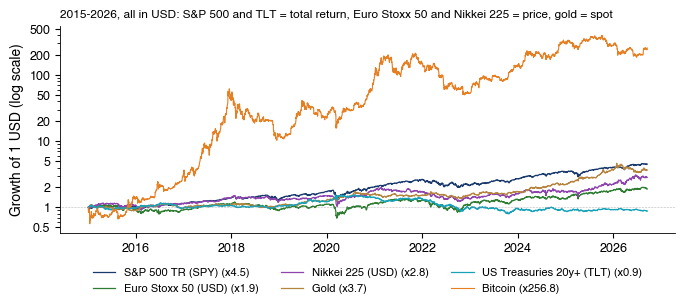

S&P 500 TR (SPY)              4.50
Euro Stoxx 50 (USD)           1.90
Nikkei 225 (USD)              2.85
Gold                          3.68
US Treasuries 20y+ (TLT)      0.88
Bitcoin                     256.80
dtype: float64

In [8]:
fig_cross_asset_growth().round(2)

**Dividends.** The gap between the S&P 500 with dividends reinvested (SPY) and the price index, 2015–2026.

In [9]:
c_tr, c_px, gap = dividend_gap()
print(f'CAGR with dividends {c_tr:.2%}, price only {c_px:.2%}, gap {gap * 100:.1f} pp a year')

CAGR with dividends 13.71%, price only 11.87%, gap 1.8 pp a year


## 2. Risk and return, 2015–2026

$\text{CAGR} = (P_T/P_0)^{1/\text{years}} - 1$ and annualised volatility $\sigma\sqrt{q}$, with $q$ the observed number of returns per year (about 252 for equities, 365 for crypto). All assets in USD; EUR/RON is the rate in RON per EUR.

In [10]:
def fig_risk_return(start='2015-01-02'):
    names = CROSS + ['Ethereum', 'EUR/USD', 'EUR/RON']
    cols = CROSS_COL + [Purple, Crimson, IDAred]
    rows = []
    panel = cross_panel()
    for n in names:
        s = (eurron if n == 'EUR/RON' else panel[n]).loc[start:].dropna()
        cagr, v = ann_stats(s, 'obs')          # q = numarul observat de zile de tranzactionare pe an
        rows.append((n, cagr, v, s.index[0]))
    res = pd.DataFrame(rows, columns=['asset', 'cagr', 'vol', 'from']).set_index('asset')
    fig, ax = plt.subplots(figsize=(6.6, 3.2))
    for (n, r), c in zip(res.iterrows(), cols):
        ax.scatter(r['vol'], r['cagr'], s=40, color=c, zorder=3)
        late = r['from'] > pd.Timestamp(start) + pd.Timedelta(days=30)
        lab = f"{n} (from {r['from']:%b %Y})" if late else n
        dx, dy, ha = OFFSETS.get(n, (5, 3, 'left'))
        ax.annotate(lab, (r['vol'], r['cagr']), xytext=(dx, dy), textcoords='offset points',
                    fontsize=7.5, ha=ha)
    ax.set_xscale('log')
    ax.set_xticks([0.02, 0.05, 0.1, 0.2, 0.4, 0.8])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_ylim(-0.08, None)
    ax.set_xlabel('Annualised volatility (log scale)')
    ax.set_ylabel('Annualised return (CAGR)')
    ax.set_title('Risk and return, 2015-2026: assets in USD, EUR/RON in RON per EUR',
                 fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch0_risk_return')
    return res

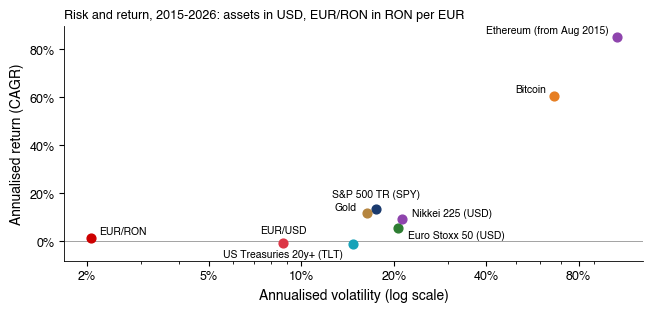

,cagr,vol,from
asset,,,
S&P 500 TR (SPY),0.137,0.176,2015-01-02
Euro Stoxx 50 (USD),0.056,0.207,2015-01-02
Nikkei 225 (USD),0.094,0.213,2015-01-05
Gold,0.118,0.163,2015-01-02
US Treasuries 20y+ (TLT),-0.010,0.147,2015-01-02
Bitcoin,0.606,0.667,2015-01-02
Ethereum,0.852,1.064,2015-08-07
EUR/USD,-0.004,0.087,2015-01-02
EUR/RON,0.014,0.021,2015-01-05


In [11]:
fig_risk_return().round(3)

## 3. Crises and drawdowns

$DD_t = P_t / \max_{s\le t} P_s - 1$: the loss from the previous peak.

In [12]:
def fig_sp500_drawdowns():
    s = px['S&P 500'].dropna()
    dd = drawdown(s)
    fig, axes = plt.subplots(2, 1, figsize=(7.0, 3.6), sharex=True, gridspec_kw={'height_ratios': [1.3, 1]})
    axes[0].plot(s.index, s.values, color=MainBlue, lw=0.8)
    log_axis(axes[0], [1000, 2000, 4000, 8000])
    axes[0].set_ylabel('S&P 500 (log)')
    axes[1].fill_between(dd.index, dd.values, 0, color=IDAred, alpha=0.35, lw=0)
    axes[1].plot(dd.index, dd.values, color=IDAred, lw=0.5)
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    axes[1].set_ylabel('Drawdown')
    res = {}
    for name, a, b in EPISODES:
        seg = dd.loc[a:b]
        t, v = seg.idxmin(), seg.min()
        res[name] = (t.date(), v)
        axes[1].annotate(f'{name}\n{v:.0%}', (t, v), xytext=(0, -2), textcoords='offset points',
                         ha='center', va='top', fontsize=7)
    axes[1].set_ylim(dd.min() * 1.45, 0.02)
    axes[0].set_title('S&P 500, 2000-2026: level (log scale) and drawdown from the running peak',
                      fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch0_sp500_drawdowns')
    return res

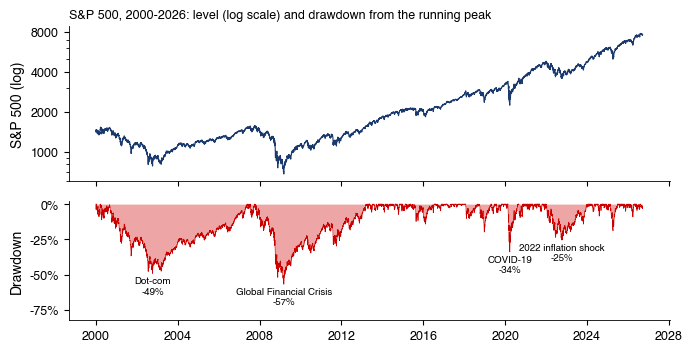

{'Dot-com': (datetime.date(2002, 10, 9), -0.4914694983829364),
 'Global Financial Crisis': (datetime.date(2009, 3, 9), -0.5677538894035716),
 'COVID-19': (datetime.date(2020, 3, 23), -0.339249600261347),
 '2022 inflation shock': (datetime.date(2022, 10, 12), -0.2542509787378666)}

In [13]:
fig_sp500_drawdowns()

## 4. Volatility regimes: the VIX

In [14]:
def fig_vix_regimes():
    v = px['VIX'].dropna()
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    ax.plot(v.index, v.values, color=MainBlue, lw=0.5)
    ax.axhline(20, color=Amber, ls='--', lw=0.8)
    ax.axhline(30, color=IDAred, ls='--', lw=0.8)
    ax.text(1.005, 20 / (v.max() * 1.18), 'VIX = 20', fontsize=7, color=Amber, transform=ax.transAxes, va='center')
    ax.text(1.005, 30 / (v.max() * 1.18), 'VIX = 30', fontsize=7, color=IDAred, transform=ax.transAxes, va='center')
    # cele mai mari varfuri, separate prin cel putin 2 ani
    peaks = []
    for t in v.sort_values(ascending=False).index:
        if all(abs((t - p).days) > 730 for p in peaks):
            peaks.append(t)
        if len(peaks) == 5:
            break
    for t in peaks:
        ax.annotate(f'{t:%b %Y}\n{v.loc[t]:.0f}', (t, v.loc[t]), xytext=(0, 4), textcoords='offset points',
                    ha='center', fontsize=7)
    ax.set_ylim(0, v.max() * 1.18)
    ax.set_ylabel('VIX (implied volatility, %)')
    share = {'<20': (v < 20).mean(), '20-30': ((v >= 20) & (v < 30)).mean(), '>=30': (v >= 30).mean()}
    ax.set_title(f'VIX 2000-2026: calm most of the time (<20 on {share["<20"]:.0%} of days), '
                 f'with short violent spikes', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch0_vix_regimes')
    return {t.date(): round(v.loc[t], 2) for t in peaks}, share

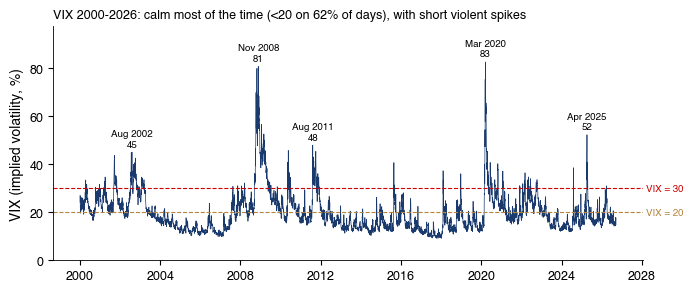

({datetime.date(2020, 3, 16): np.float64(82.69),
  datetime.date(2008, 11, 20): np.float64(80.86),
  datetime.date(2025, 4, 8): np.float64(52.33),
  datetime.date(2011, 8, 8): np.float64(48.0),
  datetime.date(2002, 8, 5): np.float64(45.08)},
 {'<20': np.float64(0.6200976764836466),
  '20-30': np.float64(0.28725765872428594),
  '>=30': np.float64(0.09264466479206748)})

In [15]:
fig_vix_regimes()

## 5. Interest rates and the yield curve (FRED)

In [16]:
def fig_rates():
    d = fred[['DGS10', 'DGS2']].dropna()
    ff = fred['FEDFUNDS'].dropna()
    spread = d['DGS10'] - d['DGS2']
    fig, axes = plt.subplots(2, 1, figsize=(7.0, 3.6), sharex=True, gridspec_kw={'height_ratios': [1.3, 1]})
    axes[0].plot(ff.index, ff.values, color=Teal, lw=0.9, label='Fed funds (monthly)')
    axes[0].plot(d.index, d['DGS2'], color=Amber, lw=0.7, label='2-year Treasury')
    axes[0].plot(d.index, d['DGS10'], color=MainBlue, lw=0.7, label='10-year Treasury')
    axes[0].set_ylabel('Yield (%)')
    h, l = axes[0].get_legend_handles_labels()
    axes[1].legend(h, l, loc='upper center', bbox_to_anchor=(0.5, -0.32), ncol=3, frameon=False, fontsize=7.5)
    axes[1].plot(spread.index, spread.values, color=MainBlue, lw=0.6)
    axes[1].fill_between(spread.index, spread.values, 0, where=spread < 0, color=IDAred, alpha=0.45, lw=0)
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_ylabel('10y - 2y (pp)')
    inv = spread.loc['2022':'2024']
    axes[0].set_title('US rates 2000-2026 and the yield-curve spread (red = inverted curve)',
                      fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch0_rates')
    runs = (spread < 0).astype(int)
    first_neg = inv[inv < 0].index.min()
    last_neg = inv[inv < 0].index.max()
    return dict(min_spread=round(spread.min(), 2), min_date=spread.idxmin().date(),
                inversion_2022_24=(first_neg.date(), last_neg.date(), int((inv < 0).sum())),
                last_10y=round(d['DGS10'].iloc[-1], 2), last_2y=round(d['DGS2'].iloc[-1], 2),
                last_date=d.index[-1].date(), last_ff=round(ff.iloc[-1], 2), share_inverted=runs.mean())

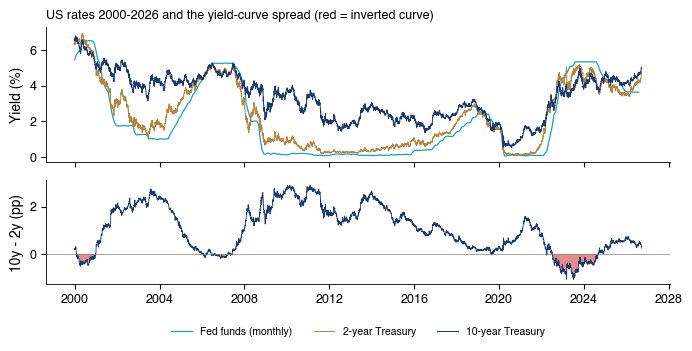

{'min_spread': -1.08,
 'min_date': datetime.date(2023, 7, 3),
 'inversion_2022_24': (datetime.date(2022, 4, 1),
  datetime.date(2024, 9, 5),
  541),
 'last_10y': np.float64(5.01),
 'last_2y': np.float64(4.76),
 'last_date': datetime.date(2026, 9, 18),
 'last_ff': np.float64(3.63),
 'share_inverted': np.float64(0.15100269380425022)}

In [17]:
fig_rates()

## 6. Diversification is not constant

Important: for a **joint** analysis (correlation, portfolio) join the **prices** on common trading days first, then take log returns, so both returns cover the same interval (Friday to Monday). For a single series use its own calendar. Differencing on a union calendar silently drops every return that follows a missing day (for equities, every Monday once crypto weekends are in the index).

In [18]:
def fig_rolling_correlations(window=252):
    eq = np.log(px['S&P 500'].dropna()).diff()              # dropna inainte de diff: calendarul propriu
    bd = np.log(px['US Treasuries 20y+ (TLT)'].dropna()).diff()
    btc = np.log(px['Bitcoin'].dropna()).diff()
    both = pd.concat([eq, bd], axis=1).dropna()
    c_sb = both.iloc[:, 0].rolling(window).corr(both.iloc[:, 1])
    # analiza comuna: join pe PRETURI in zilele comune, apoi diff -> ambele randamente acopera
    # acelasi interval (de ex. vineri -> luni); diff inainte de join ar da Bitcoin duminica -> luni
    pp = pd.concat([px['S&P 500'], px['Bitcoin']], axis=1).dropna()
    trio = np.log(pp).diff().dropna()
    c_be = trio.iloc[:, 0].rolling(window).corr(trio.iloc[:, 1])
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    ax.plot(c_sb.index, c_sb.values, color=MainBlue, lw=0.9, label='S&P 500 vs long Treasuries (TLT)')
    ax.plot(c_be.index, c_be.values, color=Orange, lw=0.9, label='S&P 500 vs Bitcoin')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_ylim(-0.8, 0.8)
    ax.set_ylabel('1-year rolling correlation')
    ax.set_title('Diversification is not constant: rolling correlations of daily log returns',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.13)
    plt.tight_layout()
    save_fig('ch0_rolling_correlations')
    return dict(sb_2010_2020=c_sb.loc['2010':'2020'].mean(), sb_2022_2026=c_sb.loc['2022':].mean(),
                sb_last=c_sb.dropna().iloc[-1], be_2016_2019=c_be.loc['2016':'2019'].mean(),
                be_2022_2026=c_be.loc['2022':].mean(), be_last=c_be.dropna().iloc[-1])


def fig_rolling_vol(window=63):
    eq = np.log(px['S&P 500'].dropna()).diff()
    btc = np.log(px['Bitcoin'].dropna()).diff()
    v_eq = eq.rolling(window).std() * np.sqrt(252)
    v_btc = btc.rolling(window).std() * np.sqrt(365)
    fig, ax = plt.subplots(figsize=(7.0, 2.9))
    ax.plot(v_btc.index, v_btc.values, color=Orange, lw=0.8, label='Bitcoin (365 days/year)')
    ax.plot(v_eq.loc['2014-09':].index, v_eq.loc['2014-09':].values, color=MainBlue, lw=0.8,
            label='S&P 500 (252 days/year)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_ylabel('Annualised volatility (63 observations)')
    ratio = (v_btc.loc['2024':].mean() / v_eq.loc['2024':].mean())
    ax.set_title(f'Rolling volatility: Bitcoin is still about {ratio:.1f} times as volatile as the S&P 500 '
                 f'(2024-2026)', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.13)
    plt.tight_layout()
    save_fig('ch0_rolling_vol')
    return dict(btc_2015_17=v_btc.loc['2015':'2017'].mean(), btc_2024_26=v_btc.loc['2024':].mean(),
                eq_2024_26=v_eq.loc['2024':].mean(), ratio=ratio)

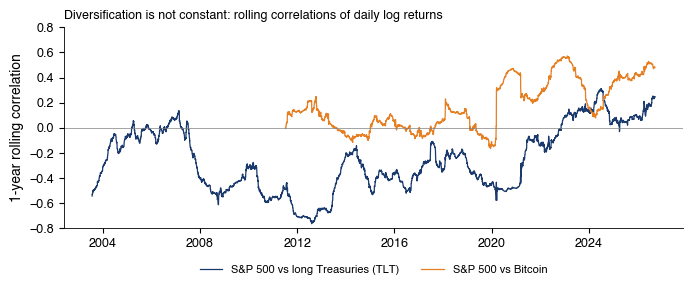

{'sb_2010_2020': np.float64(-0.42702635043750425), 'sb_2022_2026': np.float64(0.08185539931140351), 'sb_last': np.float64(0.24747709386931793), 'be_2016_2019': np.float64(0.014624120010598617), 'be_2022_2026': np.float64(0.37840122030586987), 'be_last': np.float64(0.4788167118808474)}


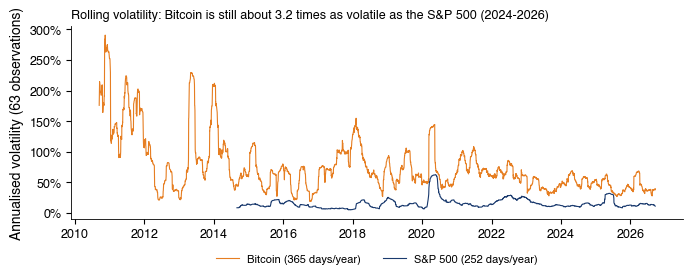

{'btc_2015_17': np.float64(0.6499221164864892), 'btc_2024_26': np.float64(0.4622319830166343), 'eq_2024_26': np.float64(0.14240894012315933), 'ratio': np.float64(3.245807339180271)}


In [19]:
print(fig_rolling_correlations())
print(fig_rolling_vol())

## 7. Market concentration: SPY vs RSP

In [20]:
def fig_concentration():
    p = px[['SPY', 'RSP']].dropna()
    ratio = (p['SPY'] / p['SPY'].iloc[0]) / (p['RSP'] / p['RSP'].iloc[0])
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9), gridspec_kw={'width_ratios': [1.25, 1]})
    for col, c, lab in [('SPY', MainBlue, 'SPY (cap-weighted)'), ('RSP', Amber, 'RSP (equal-weighted)')]:
        g = p[col] / p[col].iloc[0]
        axes[0].plot(g.index, g.values, color=c, lw=0.8, label=f'{lab}: x{g.iloc[-1]:.1f}')
    log_axis(axes[0], [0.5, 1, 2, 4, 8])
    axes[0].set_ylabel('Growth of 1 USD (log)')
    legend_outside_bottom(axes[0], ncol=1, y=-0.12)
    axes[1].plot(ratio.index, ratio.values, color=IDAred, lw=0.8)
    axes[1].axhline(1, color=Gray, lw=0.5, ls=':')
    axes[1].set_title('SPY / RSP relative performance', fontsize=8.5, loc='left')
    axes[0].set_title(f'S&P 500 ETFs, {p.index[0]:%b %Y}-2026 (total return)', fontsize=8.5, loc='left')
    plt.tight_layout()
    save_fig('ch0_concentration')
    since23 = ratio.loc['2023-01-03':]
    return dict(start=p.index[0].date(), spy=(p['SPY'].iloc[-1] / p['SPY'].iloc[0]),
                rsp=(p['RSP'].iloc[-1] / p['RSP'].iloc[0]), ratio_min=round(ratio.min(), 3),
                ratio_min_date=ratio.idxmin().date(), ratio_last=round(ratio.iloc[-1], 3),
                ratio_change_since_2023=since23.iloc[-1] / since23.iloc[0] - 1)

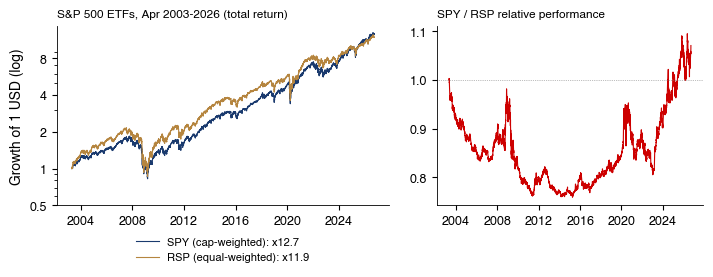

{'start': datetime.date(2003, 4, 30),
 'spy': np.float64(12.701882878330807),
 'rsp': np.float64(11.86401841999374),
 'ratio_min': 0.759,
 'ratio_min_date': datetime.date(2015, 4, 6),
 'ratio_last': np.float64(1.071),
 'ratio_change_since_2023': np.float64(0.3147161110759733)}

In [21]:
fig_concentration()

## 8. Digital assets: stablecoins and the IBIT spot Bitcoin ETF

In [22]:
def fig_stablecoins():
    s = stable[stable > 0].loc['2018':]
    fig, ax = plt.subplots(figsize=(7.0, 2.9))
    ax.fill_between(s.index, s.values, 0, color=Forest, alpha=0.25, lw=0)
    ax.plot(s.index, s.values, color=Forest, lw=0.9)
    ax.set_ylabel('USD-pegged stablecoins (bn USD)')
    pts = {}
    peak = s.loc['2022'].idxmax()                         # maximul din 2022
    trough = s.loc[peak:'2023-12-31'].idxmin()            # minimul exact de dupa maxim
    for tt in [s.loc['2020-01-01':].index[0], peak, trough, s.index[-1]]:
        pts[tt.date()] = s.loc[tt]
        ax.annotate(f'{s.loc[tt]:.1f} bn\n{tt:%d %b %Y}', (tt, s.loc[tt]), xytext=(0, 6),
                    textcoords='offset points', ha='center', fontsize=7)
    ax.set_ylim(0, s.max() * 1.25)
    ax.set_title('Total supply of USD-pegged stablecoins, 2018-2026 (source: DefiLlama)',
                 fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch0_stablecoins')
    return pts


def fig_ibit():
    d = pd.concat([px['IBIT'], ibit_volume, px['Bitcoin']], axis=1, keys=['p', 'v', 'btc']).dropna()
    dv = (d['p'] * d['v'] / 1e9)
    fig, ax = plt.subplots(figsize=(7.0, 2.9))
    ax.bar(dv.index, dv.values, width=1.0, color=MainBlue, alpha=0.35, label='IBIT daily traded value')
    ax.plot(dv.rolling(20).mean().index, dv.rolling(20).mean().values, color=MainBlue, lw=1.0,
            label='20-day average')
    ax.set_ylabel('Traded value (bn USD)')
    ax2 = ax.twinx()
    ax2.plot(d.index, d['btc'] / 1e3, color=Orange, lw=0.9, label='Bitcoin price (k USD, right)')
    ax2.set_ylabel('BTC (thousand USD)', color=Orange)
    ax2.spines['right'].set_visible(True)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3, frameon=False)
    ax.set_title('iShares Bitcoin Trust (IBIT) since launch on 11 Jan 2024: price x volume',
                 fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch0_ibit')
    return dict(first=d.index[0].date(), mean_bn=dv.mean(), median_bn=dv.median(), max_bn=dv.max(),
                max_date=dv.idxmax().date(), total_bn=dv.sum())

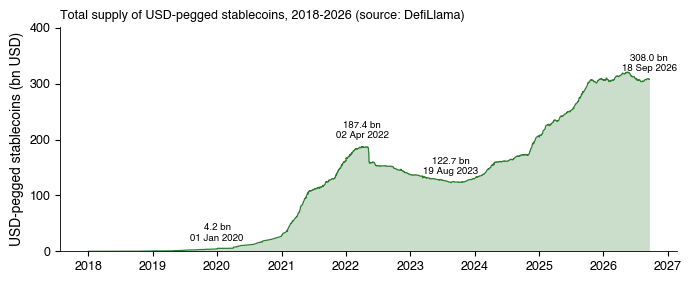

{datetime.date(2020, 1, 1): np.float64(4.171183915), datetime.date(2022, 4, 2): np.float64(187.391942652), datetime.date(2023, 8, 19): np.float64(122.660540921), datetime.date(2026, 9, 18): np.float64(308.019607521)}


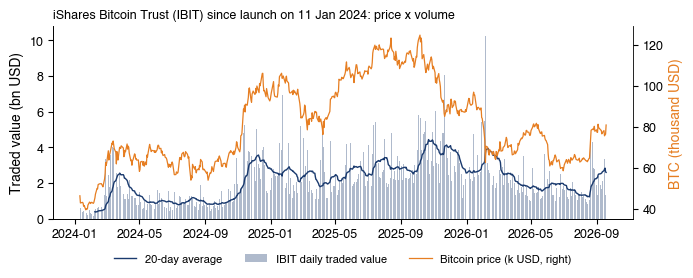

{'first': datetime.date(2024, 1, 11), 'mean_bn': np.float64(2.172763830850949), 'median_bn': 1.9651021895, 'max_bn': 10.26581115, 'max_date': datetime.date(2026, 2, 5), 'total_bn': np.float64(1464.4428219935398)}


In [23]:
print(fig_stablecoins())
print(fig_ibit())

## 9. The Romanian market

BET-TR and blue chips (dividend-adjusted), EUR/RON (BNR) and 10-year yields. The yield series are cleaned first: weekend rows and isolated outliers are removed.

In [24]:
def fig_romania():
    """BET-TR si blue chips BVB (ajustate pentru dividende), EUR/RON (BNR), randamente 10 ani RO vs DE."""
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.9), gridspec_kw={'width_ratios': [1.35, 0.9, 0.9]})
    start = '2015-01-05'
    out = {}
    b = px['BET-TR'].loc[start:].dropna()
    axes[0].plot(b.index, b / b.iloc[0], color='black', lw=1.1, label=f'BET-TR x{b.iloc[-1] / b.iloc[0]:.1f}')
    out['BET-TR'] = b.iloc[-1] / b.iloc[0]
    for n, c in zip(['Banca Transilvania', 'OMV Petrom', 'BRD', 'Transgaz', 'Romgaz'],
                    [MainBlue, Amber, Forest, Purple, Orange]):
        s_ = bvb[n].loc[start:].dropna()
        g = s_ / s_.iloc[0]
        out[n] = g.iloc[-1]
        axes[0].plot(g.index, g.values, color=c, lw=0.6, label=f'{n.split()[0]} x{g.iloc[-1]:.1f}')
    log_axis(axes[0], [0.5, 1, 2, 4, 8, 16])
    axes[0].set_ylabel('Growth of 1 RON (log)')
    axes[0].set_title('BET-TR and blue chips since 2015', fontsize=8, loc='left')
    axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2, fontsize=6, frameon=False)
    fx = eurron.loc['2005-07-01':]
    axes[1].plot(fx.index, fx.values, color=IDAred, lw=0.7)
    axes[1].set_title('EUR/RON (BNR)', fontsize=8, loc='left')
    y = pd.concat([clean_series(bonds[c].dropna()) for c in bonds], axis=1).dropna()
    axes[2].plot(y.index, y['Romania 10y'], color=MainBlue, lw=0.7, label='Romania (bonds in RON)')
    axes[2].plot(y.index, y['Germany 10y'], color=IDAred, lw=0.7, label='Germany (bonds in EUR)')
    axes[2].set_title('10-year yields (%)', fontsize=8, loc='left')
    axes[2].legend(loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2, fontsize=6, frameon=False)
    for ax in axes:
        ax.tick_params(axis='x', labelsize=7)
        ax.xaxis.set_major_locator(mdates.YearLocator(4 if ax is axes[0] else 6))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    save_fig('ch0_romania')
    r_fx = np.log(fx).diff().dropna()
    spread = (y['Romania 10y'] - y['Germany 10y'])
    return dict(growth=out, bettr_first=b.index[0].date(), eurron_first=fx.iloc[0], eurron_first_date=fx.index[0].date(),
                eurron_last=fx.iloc[-1], eurron_last_date=fx.index[-1].date(),
                eurron_vol_2015_26=ann_stats(fx.loc['2015':], 'obs')[1],
                ro10y_last=y['Romania 10y'].iloc[-1], de10y_last=y['Germany 10y'].iloc[-1],
                spread_last=spread.iloc[-1], spread_max=spread.max(), spread_max_date=spread.idxmax().date(),
                bonds_first=y.index[0].date(), h2o_first=bvb['Hidroelectrica'].first_valid_index().date())

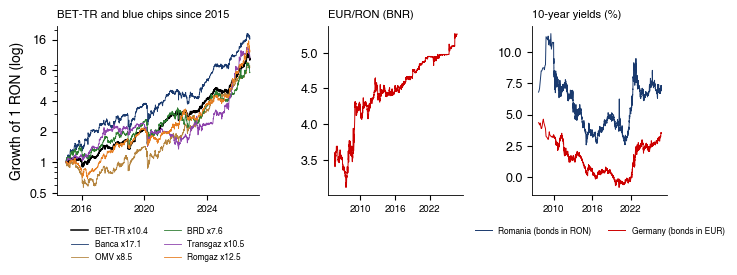

{'growth': {'BET-TR': np.float64(10.3853720024036),
  'Banca Transilvania': np.float64(17.0911366809494),
  'OMV Petrom': np.float64(8.537463976945245),
  'BRD': np.float64(7.609976433621367),
  'Transgaz': np.float64(10.487535966870142),
  'Romgaz': np.float64(12.486343062275635)},
 'bettr_first': datetime.date(2015, 1, 5),
 'eurron_first': np.float64(3.5986),
 'eurron_first_date': datetime.date(2005, 7, 4),
 'eurron_last': np.float64(5.2644),
 'eurron_last_date': datetime.date(2026, 9, 18),
 'eurron_vol_2015_26': np.float64(0.020630911621572493),
 'ro10y_last': np.float64(7.33),
 'de10y_last': np.float64(3.5296),
 'spread_last': np.float64(3.8004000000000002),
 'spread_max': 8.303,
 'spread_max_date': datetime.date(2009, 3, 2),
 'bonds_first': datetime.date(2007, 9, 3),
 'h2o_first': datetime.date(2023, 7, 12)}

In [25]:
fig_romania()

### 9b. A century of the Bucharest Stock Exchange

The exchange opened on 1 December 1882, was closed in 1948 and re-opened on 20 November 1995. The chart shows the BET index, official closing values from its launch on 19 September 1997 (base 1,000) to September 2026, on a log scale (equal distances = equal percentage changes).

In [26]:
def fig_bvb_history():
    """Indicele BET 1997-2026 pe scara log, valori oficiale de inchidere, cu evenimente marcate."""
    bet = load('BET', start='1997-01-01').dropna()
    full = bet
    fig, ax = plt.subplots(figsize=(7.2, 3.3))
    ax.plot(bet.index, bet.values, color=MainBlue, lw=0.8, label='BET, official closing values (base 1,000 on 19 Sep 1997)')
    ax.set_yscale('log')
    ax.set_ylabel('Index level (log scale)')
    events = [('1999-04-21', 'Apr 1999\nlow', 0, 18), ('2007-07-24', 'Jul 2007\npeak', 0, 14),
              ('2009-02-25', 'Feb 2009\ntrough', 0, -26), ('2018-12-18', 'Dec 2018\nbank-tax\nannouncement', -34, -16),
              ('2020-03-16', 'Mar 2020\nCOVID-19', 16, -16), ('2023-07-12', 'Jul 2023\nHidroelectrica\nIPO', 0, -16)]
    for d, lab, dx, dy in events:
        t = full.index[full.index.searchsorted(pd.Timestamp(d))]
        ax.plot(t, full.loc[t], 'o', ms=3.5, color=IDAred)
        ax.annotate(lab, xy=(t, full.loc[t]), xytext=(dx, dy), textcoords='offset points', ha='center',
                    va='bottom' if dy > 0 else 'top', fontsize=6.5, color='black',
                    arrowprops=dict(arrowstyle='-', color=LightGray, lw=0.5))
    ax.set_ylim(150, 5e4)
    ax.set_title('The BET index, 1997-2026', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=1, y=-0.13)
    plt.tight_layout()
    save_fig('ch0_bvb_history')
    lvl = lambda s, d: s.loc[s.index[s.index.searchsorted(pd.Timestamp(d))]]
    return dict(bet_first=(bet.index[0].date(), bet.iloc[0]),                 bet_1999_min=(bet.loc['1999'].idxmin().date(), bet.loc['1999'].min()),
                bet_2007_max=(bet.loc[:'2008'].idxmax().date(), bet.loc[:'2008'].max()),
                bet_2009_min=(bet.loc['2008-06':'2009-12'].idxmin().date(), bet.loc['2008-06':'2009-12'].min()),
                dec2018=(lvl(bet, '2018-12-18'), lvl(bet, '2018-12-19'), lvl(bet, '2018-12-19') / lvl(bet, '2018-12-18') - 1),
                bet_last=(bet.index[-1].date(), bet.iloc[-1]), bet_max=(bet.idxmax().date(), bet.max()),
                multiple_1997_2026=bet.iloc[-1] / bet.iloc[0])

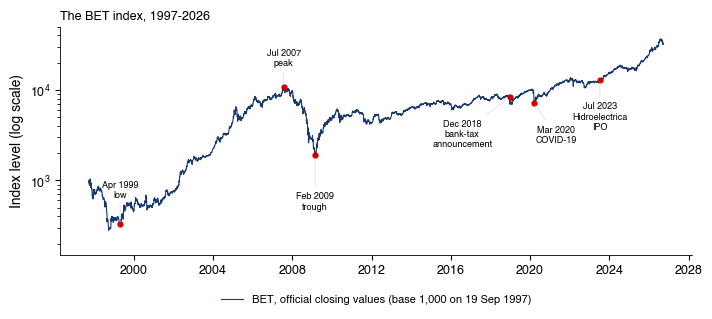

{'bet_first': (datetime.date(1997, 9, 19), np.float64(1000.0)),
 'bet_1999_min': (datetime.date(1999, 4, 21), 325.78),
 'bet_2007_max': (datetime.date(2007, 7, 24), 10813.59),
 'bet_2009_min': (datetime.date(2009, 2, 25), 1887.14),
 'dec2018': (np.float64(8419.19),
  np.float64(7475.22),
  np.float64(-0.11212123731617885)),
 'bet_last': (datetime.date(2026, 9, 18), np.float64(32757.81)),
 'bet_max': (datetime.date(2026, 8, 19), 36487.21),
 'multiple_1997_2026': np.float64(32.75781)}

In [27]:
fig_bvb_history()

## 10. Data pitfalls

The EUR/RON market file contains bad ticks of ±15% that reverse the next day. Compare its volatility with the BNR reference rate.

In [28]:
def data_pitfall():
    """EUR/RON: fisierul de piata (cu erori de cotatie) vs BNR, 2015-2026."""
    r_e = np.log(eurron_mkt).diff().dropna().loc['2015':]
    r_b = np.log(eurron).diff().dropna().loc['2015':]
    top = r_e.abs().sort_values(ascending=False).head(6)
    q = lambda r: len(r) / ((r.index[-1] - r.index[0]).days / 365.25)   # frecventa observata (FX: nu 252)
    return dict(vol_market=r_e.std() * np.sqrt(q(r_e)), vol_bnr=r_b.std() * np.sqrt(q(r_b)),
                largest={d.date(): round(r_e.loc[d], 4) for d in top.index})

In [29]:
data_pitfall()

{'vol_market': np.float64(0.12388242455784142),
 'vol_bnr': np.float64(0.02065389074837226),
 'largest': {datetime.date(2025, 8, 14): np.float64(-0.1541),
  datetime.date(2025, 8, 13): np.float64(0.154),
  datetime.date(2022, 1, 7): np.float64(-0.1222),
  datetime.date(2022, 1, 10): np.float64(0.1219),
  datetime.date(2022, 1, 5): np.float64(-0.1211),
  datetime.date(2022, 1, 6): np.float64(0.121)}}

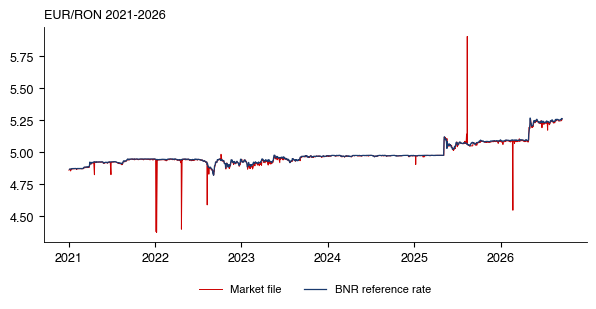

In [30]:
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(eurron_mkt.loc['2021':].index, eurron_mkt.loc['2021':].values, color=IDAred, lw=0.7, label='Market file')
ax.plot(eurron.loc['2021':].index, eurron.loc['2021':].values, color=MainBlue, lw=0.9, label='BNR reference rate')
ax.set_title('EUR/RON 2021-2026', fontsize=9, loc='left')
legend_outside_bottom(ax, ncol=2, y=-0.15)
plt.show()